# ISA Mini-Project 1 – Exploratory Data Analysis
## Spotify Million Playlist Dataset

This notebook performs EDA on the preprocessed parquet files produced by:
1. `convert.py` — combines 300 JSON slices into `mpd_raw.parquet`
2. `split_parquet.py` — splits into `playlists.parquet` and `tracks.parquet`

---
## 0. Setup

In [1]:
import os
import re
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../processed')
OUT       = Path('outputs')
OUT.mkdir(exist_ok=True)

pls  = pd.read_parquet(PROCESSED / 'playlists.parquet')
trks = pd.read_parquet(PROCESSED / 'tracks.parquet')

print(f'Playlists : {len(pls):>10,}')
print(f'Track rows: {len(trks):>10,}')

Playlists :    300,000
Track rows: 19,924,037


---
## 1. Dataset Overview

In [2]:
print('=== Playlists ===')
print(f'  Total playlists  : {len(pls):,}')
print(f'  With description : {pls["has_desc"].sum():,}  ({pls["has_desc"].mean()*100:.1f}%)')
print(f'  Collaborative    : {(pls["collaborative"]=="true").sum():,}  ({(pls["collaborative"]=="true").mean()*100:.2f}%)')
print()
print('=== Tracks ===')
print(f'  Total track entries : {len(trks):,}')
print(f'  Unique tracks       : {trks["track_uri"].nunique():,}')
print(f'  Unique artists      : {trks["artist_uri"].nunique():,}')
print(f'  Unique albums       : {trks["album_uri"].nunique():,}')

=== Playlists ===
  Total playlists  : 300,000
  With description : 5,524  (1.8%)
  Collaborative    : 6,764  (2.25%)

=== Tracks ===
  Total track entries : 19,924,037
  Unique tracks       : 1,235,456
  Unique artists      : 179,166
  Unique albums       : 447,878


---
## 2. Playlist-level Statistics

### 2.1 Trimmed summary statistics (10th – 90th percentile)

Outliers are excluded using the 10th and 90th percentile thresholds to get more representative central tendency measures.

In [3]:
TRIM_LO, TRIM_HI = 0.10, 0.90
stat_cols = ['num_tracks', 'num_artists', 'num_albums', 'num_followers', 'num_edits', 'duration_ms']

rows = []
for col in stat_cols:
    lo = pls[col].quantile(TRIM_LO)
    hi = pls[col].quantile(TRIM_HI)
    trimmed = pls[(pls[col] >= lo) & (pls[col] <= hi)][col]
    rows.append({
        'variable':        col,
        'trimmed_median':  round(trimmed.median(), 2),
        'trimmed_mean':    round(trimmed.mean(), 2),
        'trimmed_std':     round(trimmed.std(), 2),
        'p10':             round(lo, 2),
        'p90':             round(hi, 2),
    })

stats_df = pd.DataFrame(rows).set_index('variable')
stats_df

,trimmed_median,trimmed_mean,trimmed_std,p10,p90
variable,,,,,
num_tracks,49.0,57.91,34.39,15.0,148.0
num_artists,29.0,33.50,18.46,9.0,80.0
num_albums,37.0,42.98,25.13,11.0,108.0
num_followers,1.0,1.16,0.37,1.0,2.0
num_edits,10.0,13.29,10.08,3.0,43.0
duration_ms,11440549.5,13580746.53,8060463.78,3446902.2,34788015.8


### 2.2 Distribution of playlist lengths

This histogram shows the distribution of the number of tracks per playlist. 

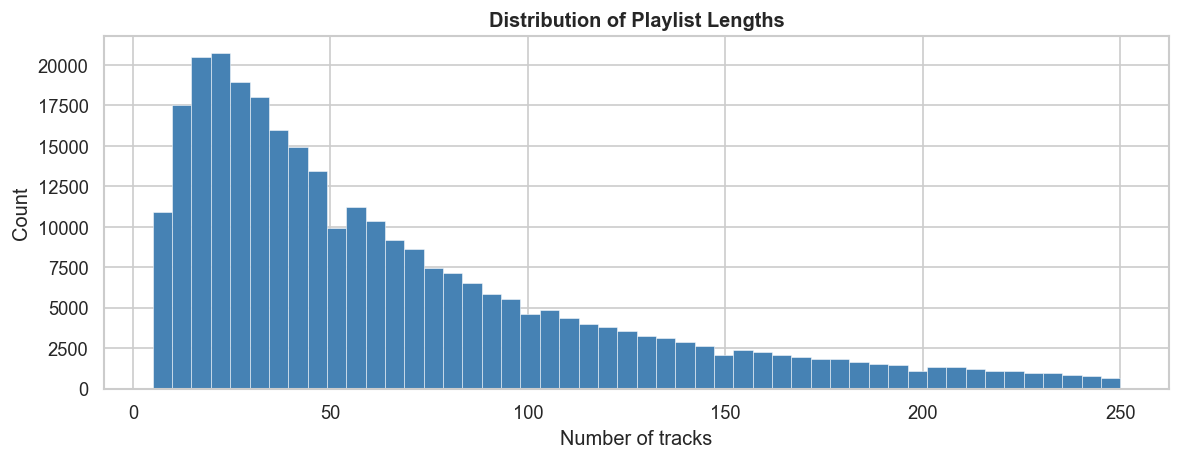

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pls['num_tracks'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Distribution of Playlist Lengths', fontweight='bold')
ax.set_xlabel('Number of tracks')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUT / 'eda_playlist_lengths.png', bbox_inches='tight')
plt.show()

The distribution is right-skewed with a peak around 20–30 tracks and a long tail extending to the maximum of 250 tracks. This tells us most users create relatively short playlists, which informs how we size the seed and holdout portions during evaluation.

### 2.3 Correlation heatmap of playlist features

This heatmap shows the pairwise correlations between all six playlist-level features. It is used to identify redundant features before modeling.

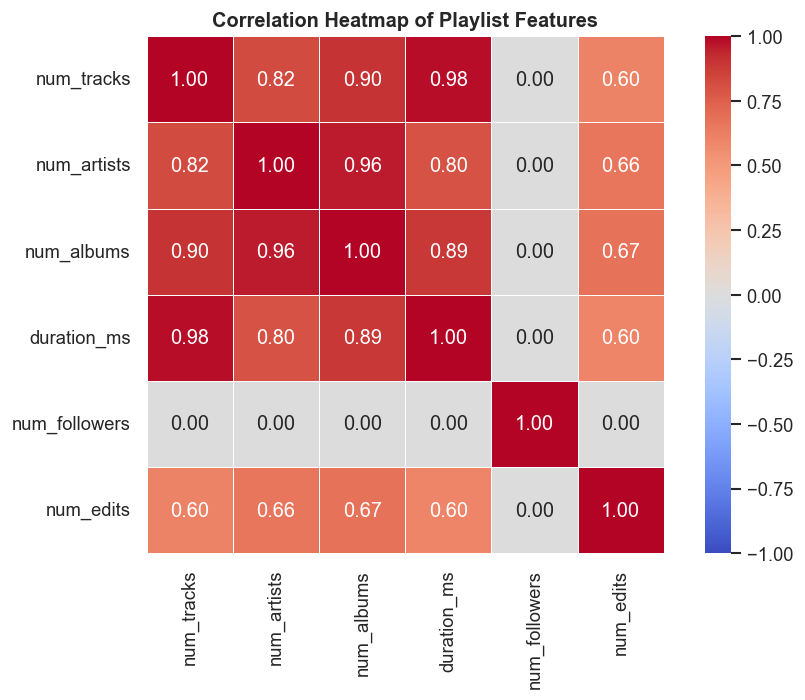

In [5]:
corr_cols = ['num_tracks', 'num_artists', 'num_albums', 'duration_ms', 'num_followers', 'num_edits']
corr = pls[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Heatmap of Playlist Features', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 2.4 Feature selection justification

Based on the correlation heatmap, the following conclusions are drawn about which playlist-level features are useful for a recommender system:

- **`num_tracks`, `num_artists`, `num_albums`, `duration_ms`** are all strongly correlated (r ≥ 0.80). They are largely redundant — `num_tracks` alone is sufficient as a proxy for playlist size.
- **`num_followers`** has near-zero correlation with every other feature (r ≈ 0.00). It carries no information about playlist composition and is not useful for recommendation. Its distribution (nearly all playlists have 1 follower) confirms this — it is essentially a constant.
- **`num_edits`** has moderate correlation with size features (r ≈ 0.60–0.67), meaning longer playlists were built over more sessions. It adds no independent signal beyond `num_tracks`.

**Conclusion:** Of the six playlist-level features, only `num_tracks` is retained for modeling. `num_followers` and `num_edits` are dropped as uninformative for track recommendation.

---
## 3. Track-level Analysis

### 3.1 Track and artist summary statistics

In [6]:
avg_dur = trks['track_dur_ms'].mean() / 1000
print('Songs summary')
print(f'  Average track duration : {avg_dur:.1f}s  ({avg_dur/60:.2f} min)')
print(f'  Unique artists         : {trks["artist_uri"].nunique():,}')
print(f'  Unique albums          : {trks["album_uri"].nunique():,}')

Songs summary
  Average track duration : 234.8s  (3.91 min)
  Unique artists         : 179,166
  Unique albums          : 447,878


### 3.2 Top 10 artists by number of tracks

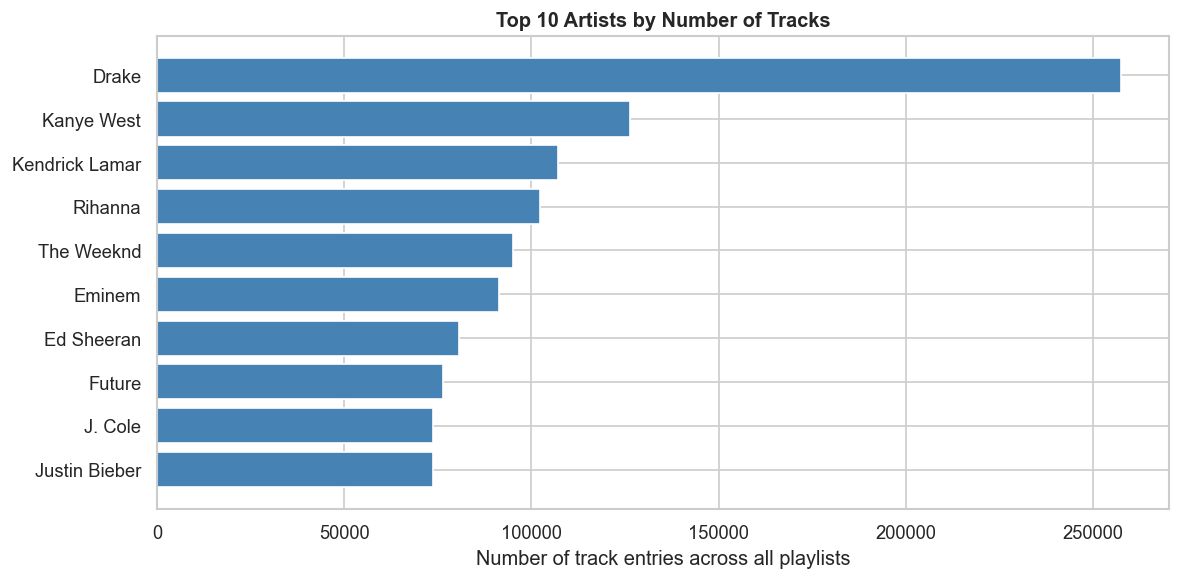

In [7]:
top_artists = (
    trks.groupby(['artist_uri', 'artist_name'])
    .size().reset_index(name='count')
    .nlargest(10, 'count')
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_artists['artist_name'][::-1], top_artists['count'][::-1], color='steelblue')
ax.set_title('Top 10 Artists by Number of Tracks', fontweight='bold')
ax.set_xlabel('Number of track entries across all playlists')
plt.tight_layout()
plt.savefig(OUT / 'eda_top_artists.png', bbox_inches='tight')
plt.show()

This bar plot displays the top 10 artists with the highest number of track entries across all playlists. It reveals strong artist-level popularity bias — Drake dominates by a large margin, roughly double the second-place artist. The recommender must account for this bias to avoid always recommending the same popular artists.

### 3.3 Top 10 albums by number of tracks

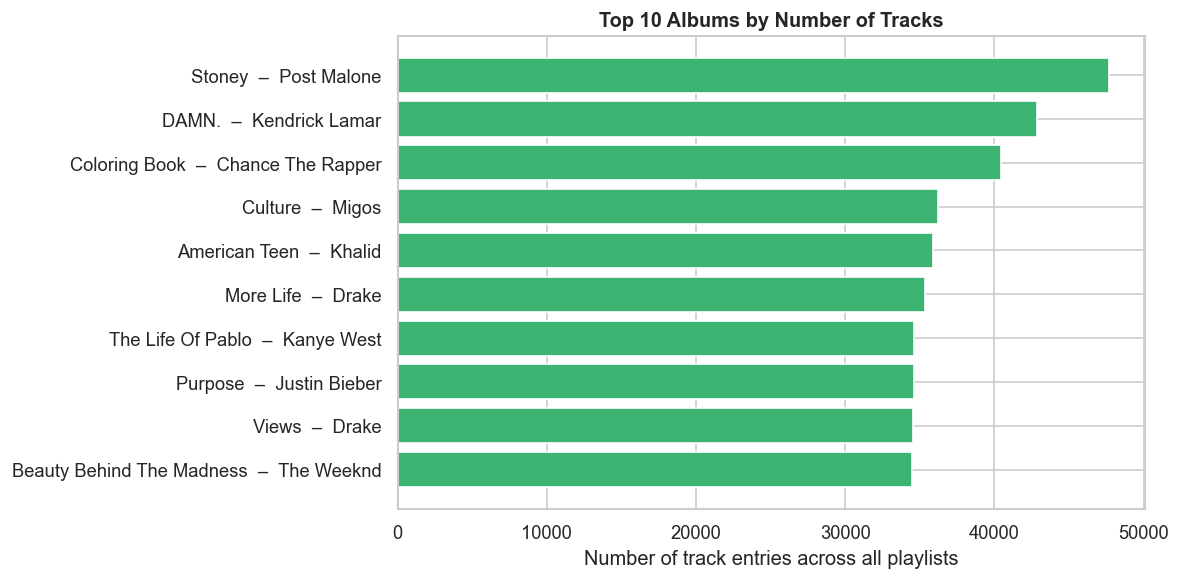

In [8]:
top_albums = (
    trks.groupby(['album_uri', 'album_name', 'artist_name'])
    .size().reset_index(name='count')
    .nlargest(10, 'count')
)
top_albums['label'] = top_albums['album_name'].str[:30] + '  –  ' + top_albums['artist_name'].str[:20]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_albums['label'][::-1], top_albums['count'][::-1], color='mediumseagreen')
ax.set_title('Top 10 Albums by Number of Tracks', fontweight='bold')
ax.set_xlabel('Number of track entries across all playlists')
plt.tight_layout()
plt.savefig(OUT / 'eda_top_albums.png', bbox_inches='tight')
plt.show()

This bar plot shows the albums with the highest number of track entries across all playlists. Recent popular albums (at the time of dataset creation) dominate. This is useful context for understanding the domain the recommender operates in.

### 3.4 Trimmed distribution of track durations

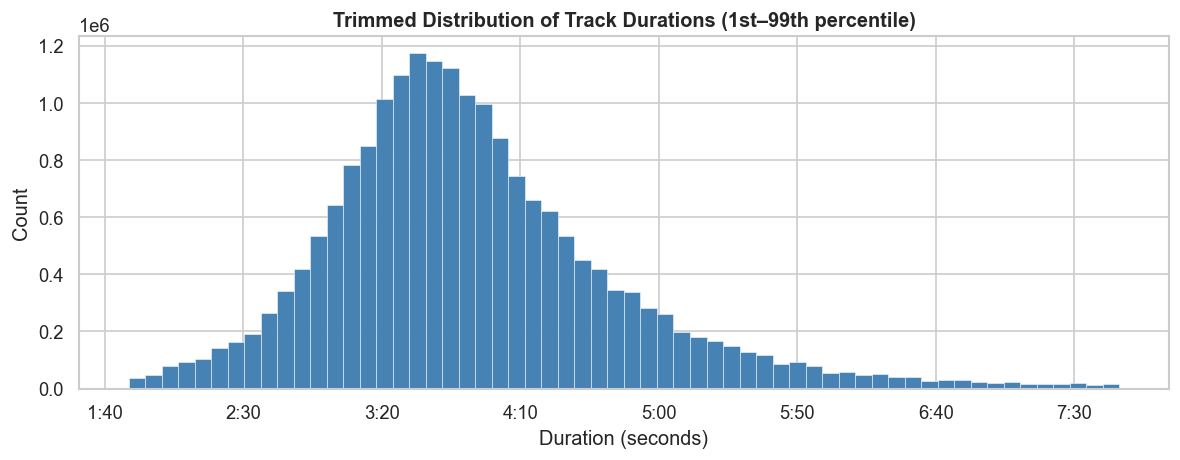

Duration range (trimmed): 109s – 466s  (1.8 – 7.8 min)
Median track duration   : 225s  (3.8 min)


In [ ]:
dur_sec = trks['track_dur_ms'] / 1000
lo, hi  = dur_sec.quantile(0.01), dur_sec.quantile(0.99)
dur_trimmed = dur_sec[(dur_sec >= lo) & (dur_sec <= hi)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dur_trimmed, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Trimmed Distribution of Track Durations (1st–99th percentile)', fontweight='bold')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x//60)}:{int(x%60):02d}'))
plt.tight_layout()
plt.savefig(OUT / 'eda_track_duration.png', bbox_inches='tight')
plt.show()

print(f'Duration range (trimmed): {lo:.0f}s – {hi:.0f}s  ({lo/60:.1f} – {hi/60:.1f} min)')
print(f'Median track duration   : {dur_trimmed.median():.0f}s  ({dur_trimmed.median()/60:.1f} min)')

This histogram shows the distribution of track durations after removing the top and bottom 1%. The distribution is approximately normal, centered around 3:20–3:40, consistent with standard streaming track lengths. No duration-based filtering is needed for the recommender — the data is already clean in this regard.

### 3.5 Top 20 reused tracks across playlists

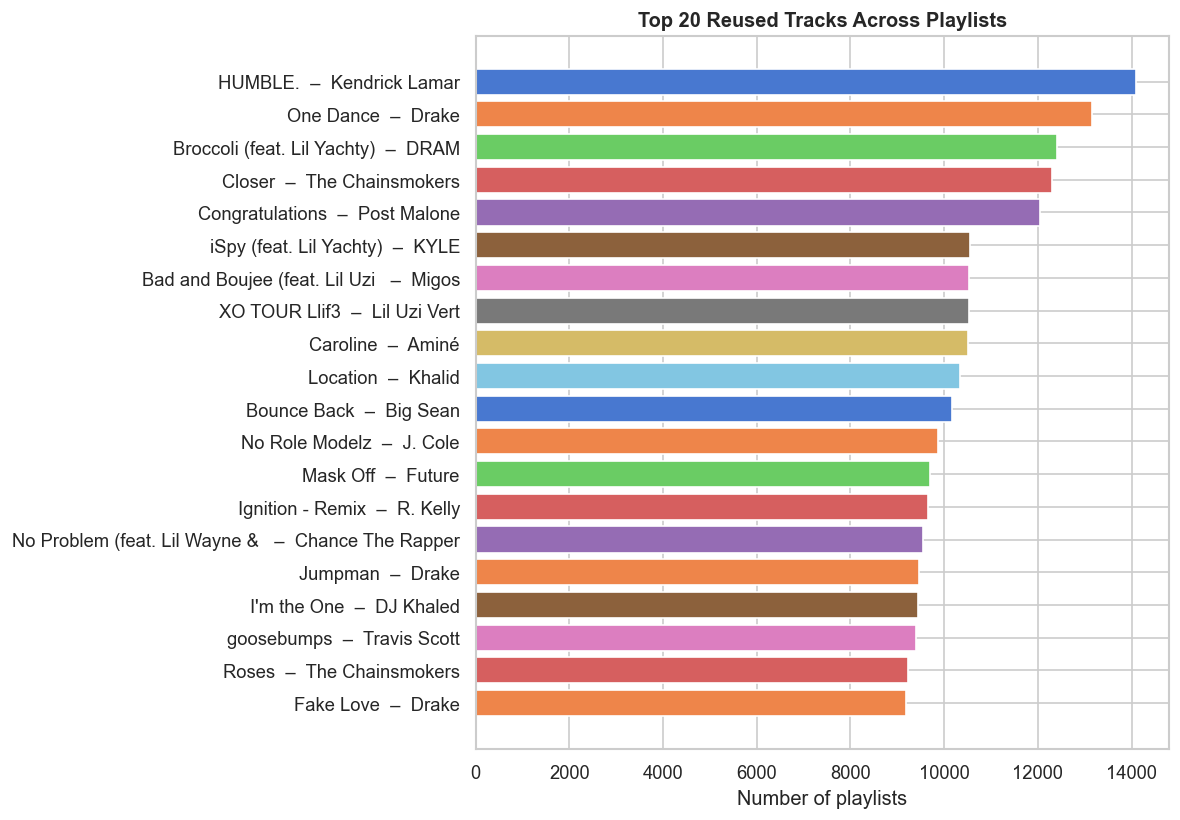

In [10]:
top_tracks = (
    trks.groupby(['track_uri', 'track_name', 'artist_name'])
    .size().reset_index(name='count')
    .nlargest(20, 'count')
)
top_tracks['label'] = top_tracks['track_name'].str[:30] + '  –  ' + top_tracks['artist_name'].str[:20]

palette = sns.color_palette('muted', top_tracks['artist_name'].nunique())
artist_colors = {a: palette[i % len(palette)] for i, a in enumerate(top_tracks['artist_name'].unique())}
colors = [artist_colors[a] for a in top_tracks['artist_name'][::-1]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_tracks['label'][::-1], top_tracks['count'][::-1], color=colors)
ax.set_title('Top 20 Reused Tracks Across Playlists', fontweight='bold')
ax.set_xlabel('Number of playlists')
plt.tight_layout()
plt.savefig(OUT / 'eda_top_tracks.png', bbox_inches='tight')
plt.show()

This bar plot shows the most frequently occurring tracks across all playlists, color-coded by artist. These tracks are the strongest candidates for a popularity-based recommender baseline. The counts also quantify how dominant individual tracks are — the top track (HUMBLE. by Kendrick Lamar) appears in ~14,000 out of 300,000 playlists (~4.7%).

### 3.6 Track and artist popularity (power-law)

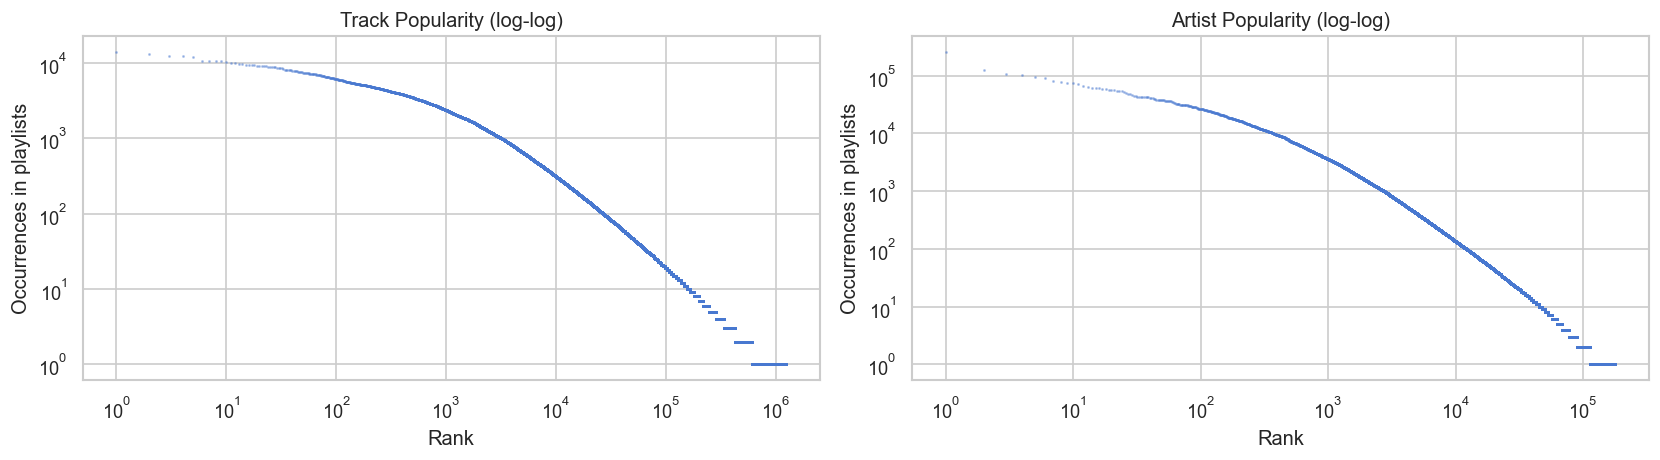

Track coverage by top-k%:
  Top   1% of tracks → 58.0% of all playlist entries
  Top   5% of tracks → 79.4% of all playlist entries
  Top  10% of tracks → 86.3% of all playlist entries
  Top  50% of tracks → 96.9% of all playlist entries


In [ ]:
track_counts  = trks['track_uri'].value_counts()
artist_counts = trks['artist_uri'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, label in [
    (axes[0], track_counts,  'Track'),
    (axes[1], artist_counts, 'Artist'),
]:
    ax.loglog(range(1, len(counts)+1), counts.values, '.', markersize=1.5, alpha=0.4)
    ax.set_title(f'{label} Popularity (log-log)')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Occurrences in playlists')

plt.tight_layout()
plt.savefig(OUT / 'eda_popularity_powerlaw.png', bbox_inches='tight')
plt.show()

print('Track coverage by top-k%:')
for pct in [1, 5, 10, 50]:
    n   = int(len(track_counts) * pct / 100)
    cov = track_counts.iloc[:n].sum() / track_counts.sum() * 100
    print(f'  Top {pct:3d}% of tracks → {cov:.1f}% of all playlist entries')

These log-log plots show that both track and artist popularity follow a power-law distribution — a small number of tracks and artists account for a disproportionately large share of all playlist entries. This directly justifies using a popularity-weighted baseline as the first recommender model. It also highlights the long-tail problem: the vast majority of tracks appear in very few playlists, making them difficult to recommend reliably without more sophisticated models.

---
## 4. Playlist Name Analysis

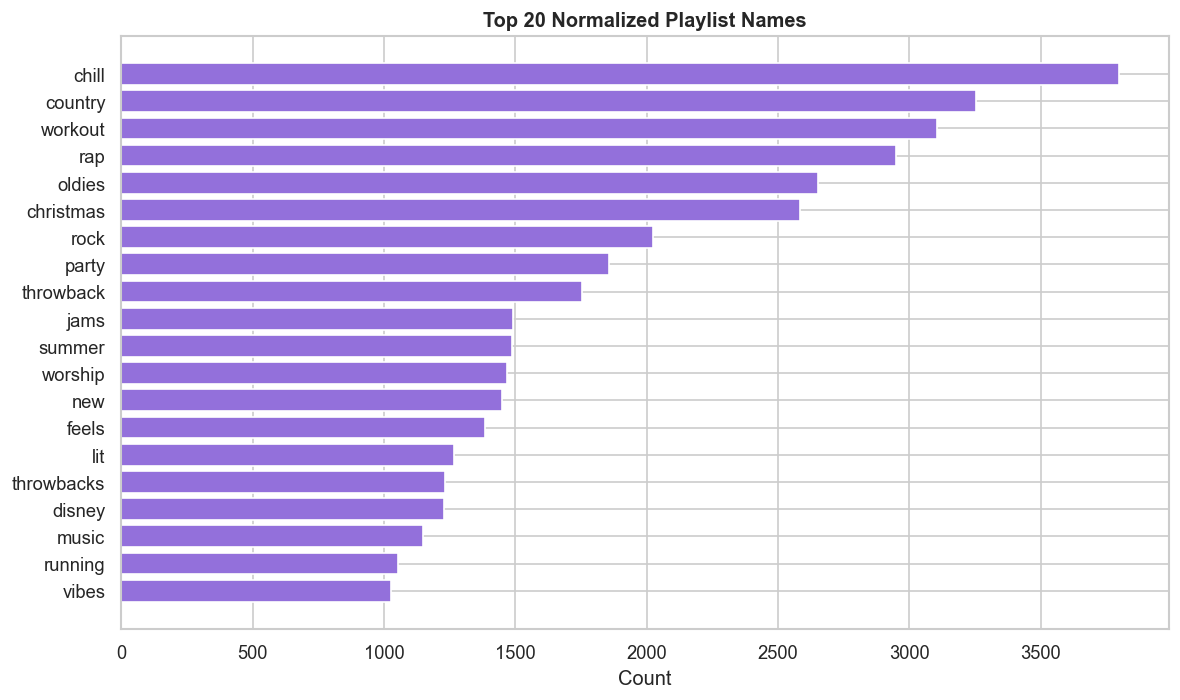

In [12]:
def normalize_name(name):
    name = name.lower()
    name = re.sub(r"[.,\/#!$%\^\*;:{}=\_`~()@]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

pls['name_norm'] = pls['name'].apply(normalize_name)
top_names = pls['name_norm'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_names.index[::-1], top_names.values[::-1], color='mediumpurple')
ax.set_title('Top 20 Normalized Playlist Names', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig(OUT / 'eda_playlist_names.png', bbox_inches='tight')
plt.show()

This bar plot shows the most common playlist names after normalization (lowercased, punctuation removed). Names cluster into clear mood and genre themes — chill, country, workout, rap, oldies — confirming that playlist names carry semantic signal. This is useful for cold-start recommendation when no track history is available, as a playlist name alone can give strong hints about what tracks belong in it.

---
## 5. Summary of EDA Findings

| Finding | Implication for modeling |
|---|---|
| Power-law track distribution | Popularity baseline is a strong signal; rare items need special handling |
| Median playlist ~30 tracks, right-skewed | Informs seed/holdout split sizing; most playlists are short |
| `num_tracks`, `num_artists`, `num_albums`, `duration_ms` strongly correlated (r ≥ 0.80) | Only `num_tracks` is needed; the rest are redundant |
| `num_followers` and `num_edits` uncorrelated with composition | Not useful features for recommendation; dropped |
| Track durations concentrate around 3:20–3:40 | No duration filtering needed |
| Playlist names cluster into genre/mood themes | Name embeddings can support cold-start recommendation |
| ~20% of playlists have descriptions | Descriptions are a sparse auxiliary feature |